# Objetivo do trabalho
Uso do alexNet para detecção de cancer de intestino

## Se no google Colab:

### Download do LC25000 através do kaggle

In [16]:
from google.colab import files
!pip install -q kaggle

In [20]:
def upload_kaggle_dataset_in_colab():
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

def unzip_kaggle_dataset_in_colab():
    !kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
    !unzip -q lung-and-colon-cancer-histopathological-images.zip

def unzip_support_functions_in_colab():
    !kaggle datasets download -d gabrielcruzvazsantos/colon-detection-support-functions
    !unzip -q colon-detection-support-functions.zip


def get_kaggle_dataset_in_colab():
    upload_kaggle_dataset_in_colab()
    unzip_kaggle_dataset_in_colab()
    unzip_support_functions_in_colab()

In [21]:
get_kaggle_dataset_in_colab()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.74G/1.76G [00:15<00:00, 218MB/s]
100% 1.76G/1.76G [00:16<00:00, 118MB/s]
Dataset URL: https://www.kaggle.com/datasets/gabrielcruzvazsantos/colon-detection-support-functions
License(s): unknown
  0% 0.00/4.00k [00:00<?, ?B/s]
100% 4.00k/4.00k [00:00<00:00, 14.7MB/s]


## Se no kaggle:

In [9]:
import sys
sys.path.append('gabrielcruzvazsantos_colon_detection_support_functions_path')

In [7]:
colon_image_path = "andrewmvd_lung_and_colon_cancer_histopathological_images_path"
colon_csv_path = "/kaggle/working/nb_lc25000.csv"

## Uso de código externo
Esse notebook foi preparado para utilizar código modular python externo que, para seu devido funcionamento, precisa ser feito o upload via

### Datasets e dataLoader

In [22]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders

In [24]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 27810.21it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [25]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test)

### Modelo e treinamento
- AlexNet
- Canais de entrada - imagem RGB: 3
- Saída - Problema de classificação binária: 2
- Taxa de aprendizado: 1e-4

In [26]:
import torch
import torchvision

In [ ]:
in_channels = 3
output_features = 2
learning_rate = 1e-4

In [28]:
model = torchvision.models.alexnet(num_classes=output_features)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [29]:
from train_and_test_model import train_model, test_model

In [30]:
model = model.to("cuda")

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer)

Epoch 1: Train Loss = 0.6953 | Val Loss = 0.6931
Epoch 2: Train Loss = 0.6965 | Val Loss = 0.6925
Epoch 3: Train Loss = 0.7000 | Val Loss = 0.6930
Epoch 4: Train Loss = 0.6936 | Val Loss = 0.6612
Epoch 5: Train Loss = 0.6550 | Val Loss = 0.6663
Epoch 6: Train Loss = 0.5887 | Val Loss = 0.3561
Epoch 7: Train Loss = 0.5157 | Val Loss = 0.2814
Epoch 8: Train Loss = 0.4535 | Val Loss = 0.2599
Epoch 9: Train Loss = 0.4001 | Val Loss = 0.2203
Epoch 10: Train Loss = 0.3557 | Val Loss = 0.1642


#### imprimindo resultados do treinamento e validação

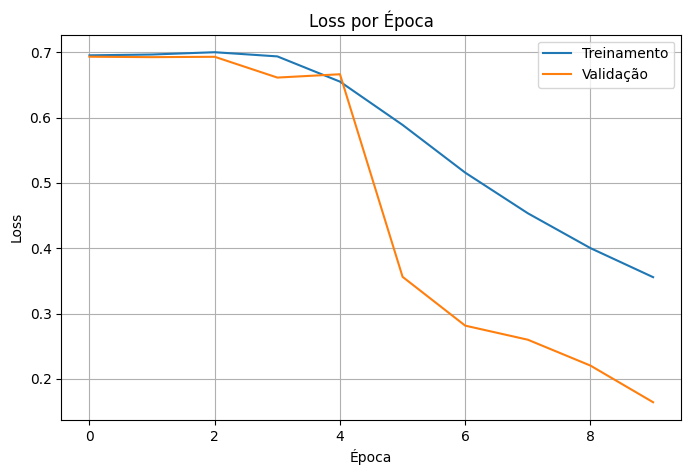

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Testando modelo

In [33]:
acc, precision, recall, f1, cm = test_model(model, "cuda", dataloader_test)

Acurácia: 0.9425
Precisão (weighted): 0.9450
Recall (weighted): 0.9425
F1-score (weighted): 0.9424
Matriz de Confusão:
[[980  20]
 [ 95 905]]


In [34]:
from tabulate import tabulate
import seaborn as sns

In [35]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.9425 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.945  │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.9425 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.9424 │
╘═════════════════════╧═════════╛


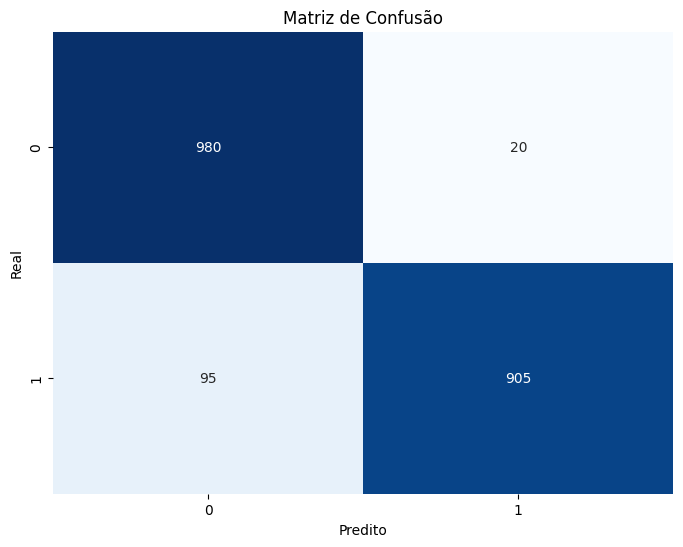

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Treinamento e teste com alteração na primeira camada da AlexNet

In [37]:
class Alexnet(torch.nn.Module):
    def __init__(self, in_channels, output_features):
        super(Alexnet, self).__init__()
        model = torchvision.models.alexnet(num_classes=output_features)
        model.features[0] = torch.nn.Conv2d(
            in_channels, 64,
            kernel_size=11, stride=4, padding=2
        )
        self.model = model

    def forward(self, x):
        return self.model(x)

changed_model = Alexnet(in_channels=in_channels, output_features=output_features)


In [38]:
changed_model = changed_model.to("cuda")

In [ ]:
optimizer = torch.optim.Adam(changed_model.parameters(), lr=learning_rate)

In [ ]:
train_losses, val_losses, best_model = train_model(changed_model, dataloader_train, dataloader_validation, optimizer)

Epoch 1: Train Loss = 0.7018 | Val Loss = 0.6923
Epoch 2: Train Loss = 0.6737 | Val Loss = 0.5172
Epoch 3: Train Loss = 0.5698 | Val Loss = 0.4067
Epoch 4: Train Loss = 0.3577 | Val Loss = 0.2124
Epoch 5: Train Loss = 0.2912 | Val Loss = 0.2272
Epoch 6: Train Loss = 0.2461 | Val Loss = 0.1566
Epoch 7: Train Loss = 0.2223 | Val Loss = 0.1194
Epoch 8: Train Loss = 0.1607 | Val Loss = 0.0365
Epoch 9: Train Loss = 0.1945 | Val Loss = 0.1071
Epoch 10: Train Loss = 0.1464 | Val Loss = 0.1304


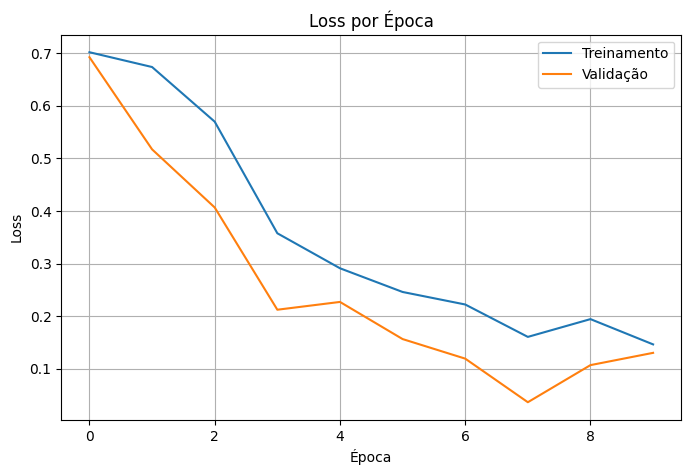

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
acc, precision, recall, f1, cm = test_model(changed_model, "cuda", dataloader_test)

Acurácia: 0.9540
Precisão (weighted): 0.9579
Recall (weighted): 0.9540
F1-score (weighted): 0.9539
Matriz de Confusão:
[[1000    0]
 [  92  908]]


In [42]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.954  │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9579 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.954  │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.9539 │
╘═════════════════════╧═════════╛


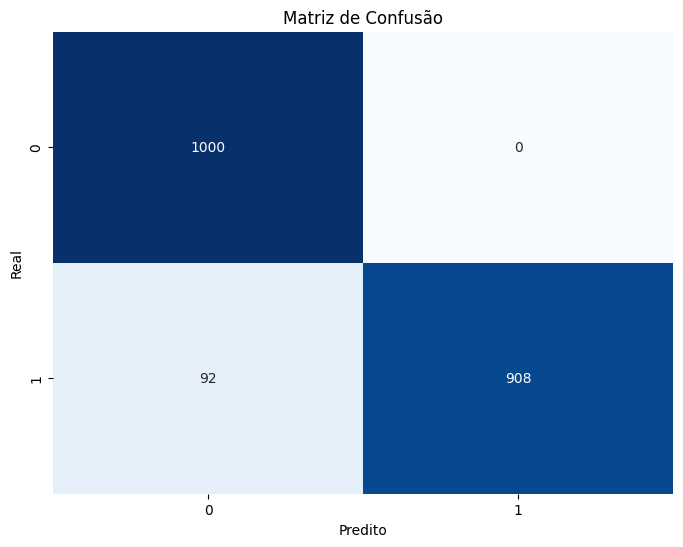

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()